In [1]:
import os
import gc
import glob
from collections import defaultdict

from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, to_tree

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

from pycirclize import Circos

from pycirclize import Circos
from pycirclize.utils import ColorCycler

import seaborn as sns

import anndata as ad
import scanpy as sc

%matplotlib inline

In [2]:
## Read In Data ##

adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_annotated_w_celltypist_scanvi.h5ad')

## Toss Stressed Glia & Doublets ##

adata = adata[~(adata.obs['subclass_annotations'] == 'Stressed Glia') & ~adata.obs['pred_dbl']].copy()
gc.collect()

# Note Stressed Glia is not large enough for statistical testing, 
#adata[adata.obs['subclass_annotations'] == 'Stressed Glia'].shape[0]
# 858 # despite contribution from multiple donors, manuscripts but dominated by Walsh/Studer MEL-1 line

3527

In [3]:
## Refrorm Categories as Str For Proper Coloring ##

adata.obs['subclass_annotations'] = adata.obs['subclass_annotations'].astype('str')
adata.obs['subclass_annotations_markers'] = adata.obs['subclass_annotations_markers'].astype('str')
adata.obs['subtype_cluster_annotations'] = adata.obs['subtype_cluster_annotations'].astype('str')
adata.obs['subtype_cluster_annotations_markers'] = adata.obs['subtype_cluster_annotations_markers'].astype('str')

In [4]:
## Correct CP / Choroid Plexus Distinction ##

adata.obs['subtype_cluster_annotations'] = adata.obs['subtype_cluster_annotations'].str.replace('Choroid Plexus ', 'CP-')
adata.obs['subtype_cluster_annotations_markers'] = adata.obs['subtype_cluster_annotations_markers'].str.replace('Choroid Plexus ', 'CP-')

In [5]:
subclass_markers_order = ['Proliferative Radial Glia SOX2+HES6+TOP2A+', 'Radial Glia SOX2+PAX6+FABP7+', 
                          'Radial Glia SOX2+VIM+FABP7+', 'Hindbrain Neurons NR2F2+PBX3+LHX1+', 'Mixed Neurons FGF12+GRIN2B+CAMK2B+', 
                          'GABAergic GAD1+GAD2+CALB2+', 'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+',
                          'Mesenchymal-like cells VIM+VCAN+SPARC+']

# Make the 'subclass_annotations_markers' column a categorical type with the custom order
adata.obs['subclass_annotations_markers'] = pd.Categorical(adata.obs['subclass_annotations_markers'], 
                                                           categories=subclass_markers_order, ordered=True)

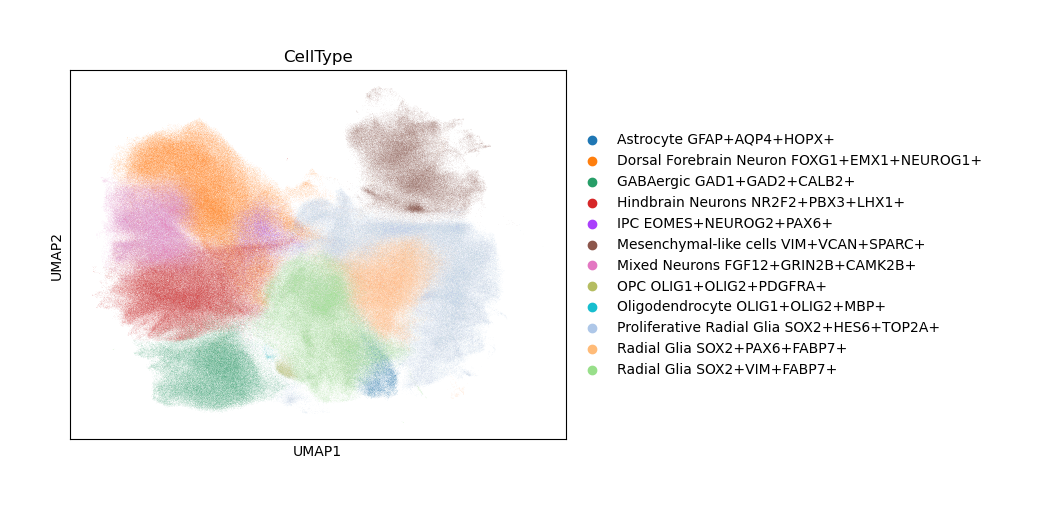

In [6]:
sc.pl.umap(adata, color='CellType')

In [7]:
# adata.uns['CellType_colors'] 

# ['#1f77b4',
#  '#ff7f0e',
#  '#279e68',
#  '#d62728',
#  '#aa40fc',
#  '#8c564b',
#  '#e377c2',
#  '#b5bd61',
#  '#17becf',
#  '#aec7e8',
#  '#ffbb78',
#  '#98df8a']

In [20]:
def plot_circos_layers(
    adata,
    outer_col,
    track_layout,                 # list of (column, thickness)
    cmaps=None,                   # list of cmap names OR list-of-color-lists
    outer_cmap="tab20",
    spacing=1,
    outer_thickness=4,
    sector_space=1,
    outer_label=True,
    legend=False,
    savefig=False):
    """
    Multi-layer circos plot with customizable colormaps.

    Parameters
    ----------
    adata : AnnData

    outer_col : str
        Column defining sectors.

    track_layout : list
        Example:
            [
                ("Diagnosis", 4),
                ("Sex", 4),
            ]

    cmaps : list
        Each item can be:
            - matplotlib cmap string
            - list of hex colors

    outer_cmap : str or list
        Colormap for outer sectors.

    savefig : bool or str
        False -> no save
        str   -> filepath prefix
    """

    # --------------------------------------------------
    # Validate columns
    # --------------------------------------------------
    needed_cols = [outer_col] + [c for c, _ in track_layout]

    missing = [
        c for c in needed_cols
        if c not in adata.obs.columns
    ]

    if len(missing) > 0:
        raise ValueError(
            f"Missing columns in adata.obs: {missing}"
        )

    # --------------------------------------------------
    # Color helper
    # --------------------------------------------------
    def generate_colors(cmap, n):
        """
        Generate n colors from:
            - matplotlib cmap name
            - explicit color list
        """

        # explicit color list
        if isinstance(cmap, list):

            if len(cmap) < n:
                mult = (n // len(cmap)) + 1
                cmap = (cmap * mult)[:n]

            return cmap[:n]

        # matplotlib cmap
        mpl_cmap = plt.get_cmap(cmap)

        return [
            mcolors.to_hex(
                mpl_cmap(i / max(n - 1, 1))
            )
            for i in range(n)
        ]

    # --------------------------------------------------
    # Build sectors
    # --------------------------------------------------
    # preserve Scanpy categorical order
    categories = list(
        adata.obs[outer_col].cat.categories
    )
    
    ct_counts = (
        adata.obs[outer_col]
        .value_counts()
        .reindex(categories)
    )
    
    sectors = ct_counts.to_dict()

    circos = Circos(
        sectors,
        space=sector_space
    )

    # --------------------------------------------------
    # Default colormaps
    # --------------------------------------------------
    if cmaps is None:
        cmaps = [
            "tab20",
            "Set2",
            "tab20b",
            "Set3",
            "Pastel1",
        ]

    if len(cmaps) < len(track_layout):
        mult = (len(track_layout) // len(cmaps)) + 1
        cmaps = (cmaps * mult)[:len(track_layout)]

    # --------------------------------------------------
    # Build mappings + colors
    # --------------------------------------------------
    layer_mappings = {}
    layer_colors = {}

    for i, (col, _) in enumerate(track_layout):

        vc = adata.obs[
            [outer_col, col]
        ].value_counts()

        mapping = defaultdict(list)

        for (ct, sub), count in vc.items():
            mapping[ct].append((sub, count))

        # sort by abundance
        for ct in mapping:
            mapping[ct].sort(
                key=lambda x: x[1],
                reverse=True
            )

        layer_mappings[col] = mapping

        # consistent global colors
        unique_vals = list(
            adata.obs[col]
            .dropna()
            .unique()
        )

        colors = generate_colors(
            cmaps[i],
            len(unique_vals)
        )

        layer_colors[col] = dict(
            zip(unique_vals, colors)
        )

    # --------------------------------------------------
    # Draw inner tracks
    # --------------------------------------------------
    current_r = 70

    for i, (col, thickness) in enumerate(track_layout):

        r0 = current_r
        r1 = r0 + thickness

        for sector in circos.sectors:

            track = sector.add_track((r0, r1))

            start = 0

            for label, count in layer_mappings[col][sector.name]:

                track.rect(
                    start=start,
                    end=start + count,
                    fc=layer_colors[col].get(
                        label,
                        "lightgrey"
                    ),
                    ec=None,
                )

                start += count

        current_r = r1 + spacing

    # --------------------------------------------------
    # Outer ring
    # --------------------------------------------------
    outer_r0 = current_r
    outer_r1 = outer_r0 + outer_thickness

    sector_names = [
        s.name for s in circos.sectors
    ]

    outer_colors_list = generate_colors(
        outer_cmap,
        len(sector_names)
    )

    outer_colors = dict(
        zip(
            sector_names,
            outer_colors_list
        )
    )

    for sector in circos.sectors:

        circos.rect(
            r_lim=(outer_r0, outer_r1),
            deg_lim=sector.deg_lim,
            fc=outer_colors[sector.name],
            ec="black",
            lw=0.5,
        )

        if outer_label:

            center_deg = (
                sum(sector.deg_lim) / 2
            )

            circos.text(
                str(sector.name),
                r=outer_r1 + 4,
                deg=center_deg,
                adjust_rotation=True,
                size=8,
            )

    # --------------------------------------------------
    # Render figure
    # --------------------------------------------------
    fig = circos.plotfig()

    # --------------------------------------------------
    # Legend
    # --------------------------------------------------
    if legend:

        handles = []
        labels = []

        for col in layer_colors:

            for k, v in layer_colors[col].items():

                handles.append(
                    Rectangle(
                        (0, 0),
                        1,
                        1,
                        color=v
                    )
                )

                labels.append(
                    f"{col}: {k}"
                )

        fig.legend(
            handles,
            labels,
            loc="center left",
            bbox_to_anchor=(1.05, 0.5),
            fontsize=6,
            frameon=False,
        )

    # --------------------------------------------------
    # Save
    # --------------------------------------------------
    if savefig:
        print('savefig triggered')
        if isinstance(savefig, str):

            outdir = os.path.dirname(savefig)
            print('outdir')
            if outdir != "":
                os.makedirs(
                    outdir,
                    exist_ok=True
                )

            fig.savefig(f"{savefig}.png", bbox_inches="tight", dpi=300)

            fig.savefig(
                f"{savefig}.svg",
                bbox_inches="tight",
            )

        else:
            raise ValueError("savefig must be False or filepath string")

    return fig, circos

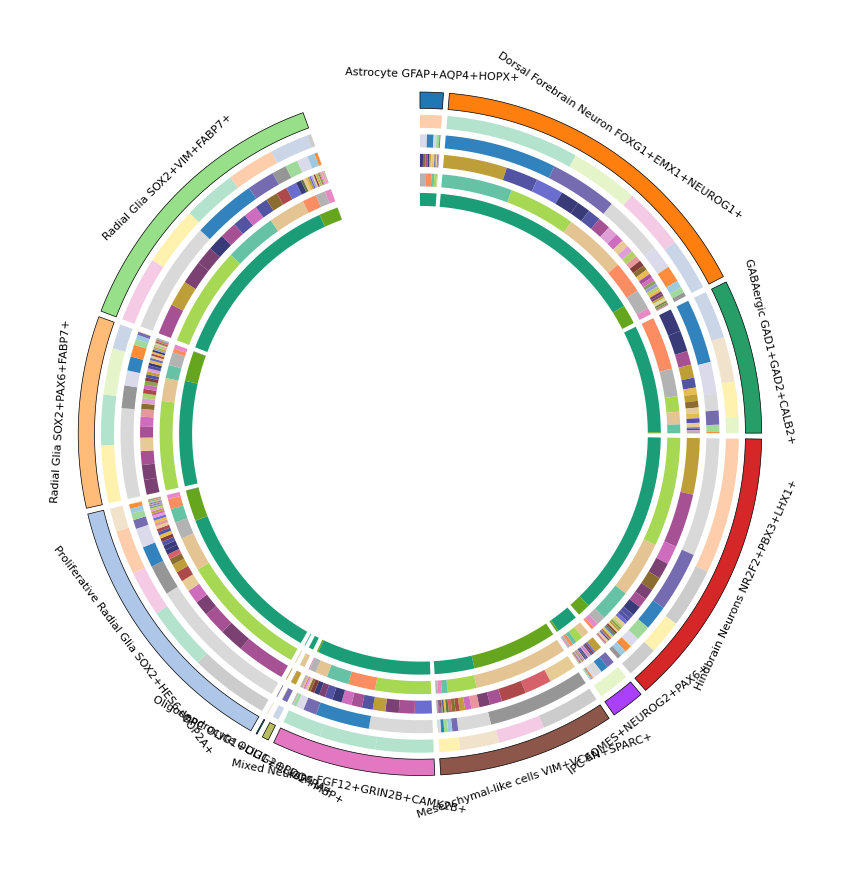

In [69]:
fig, circos = plot_circos_layers(
    adata,

    # outer sectors
    outer_col="CellType",

    # spacing between sectors
    sector_space=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 20],

    # inner tracks
    track_layout=[
        ("Chemistry", 4),
        ("Protocol", 4),
        ("Donor", 4),
        ("Manuscript", 4),
        ("subtype_cluster_annotations", 4),
    ],

    # colormaps for each inner layer
    cmaps=[
        "Dark2",
        "Set2",
        "tab20b",
        "tab20c",
        "Pastel2",
    ],

    # use Scanpy-defined cell type colors
    outer_cmap=adata.uns["CellType_colors"],

    # radial spacing between tracks
    spacing=2,

    # outer ring thickness
    outer_thickness=5,

    # labels + legend
    outer_label=True,
    legend=False,

    # save path prefix OR False
    savefig=False)

savefig triggered
outdir


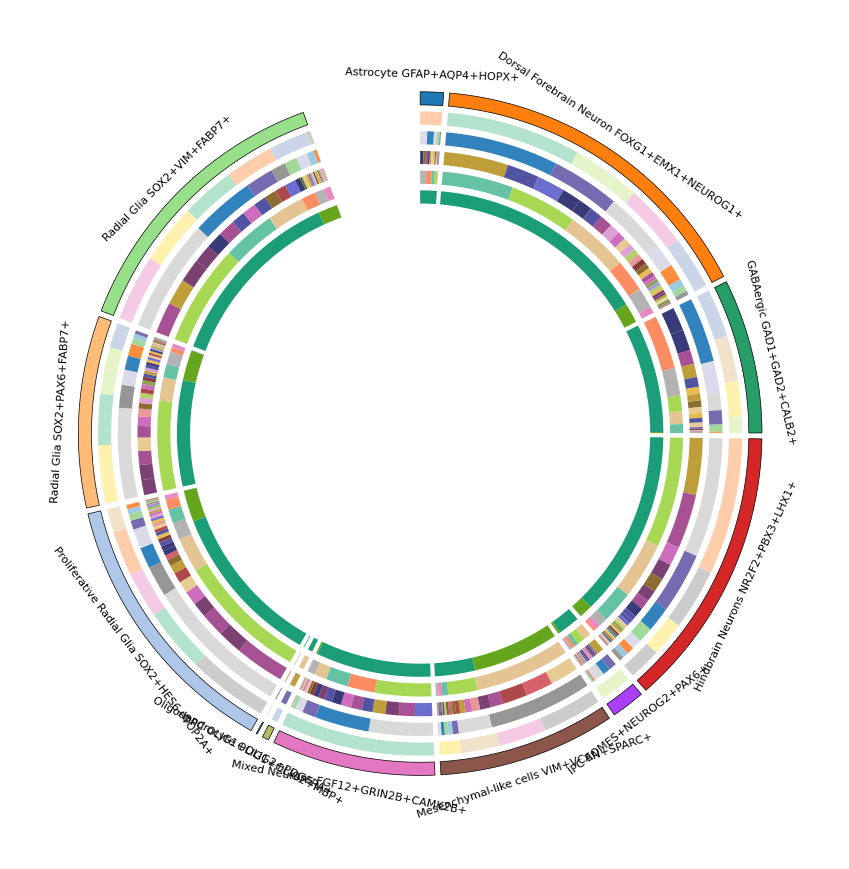

In [34]:
fig, circos = plot_circos_layers(
    adata,
    outer_col="CellType",
    sector_space=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 20],
    outer_cmap=adata.uns["CellType_colors"],
    track_layout=[
        ("Chemistry", 4),
        ("Protocol", 4),
        ("Donor", 4),
        ("Manuscript", 4),
        ("subtype_cluster_annotations", 4),
    ],
    spacing=2,
    legend=False,
    cmaps = ["Dark2", "Set2", "tab20b",  "tab20c", "Pastel2"], 
    savefig="/home/deepak/datasets/scz_meta_analysis/panels/Fig_1_Circos_All_Layers")

savefig triggered
outdir


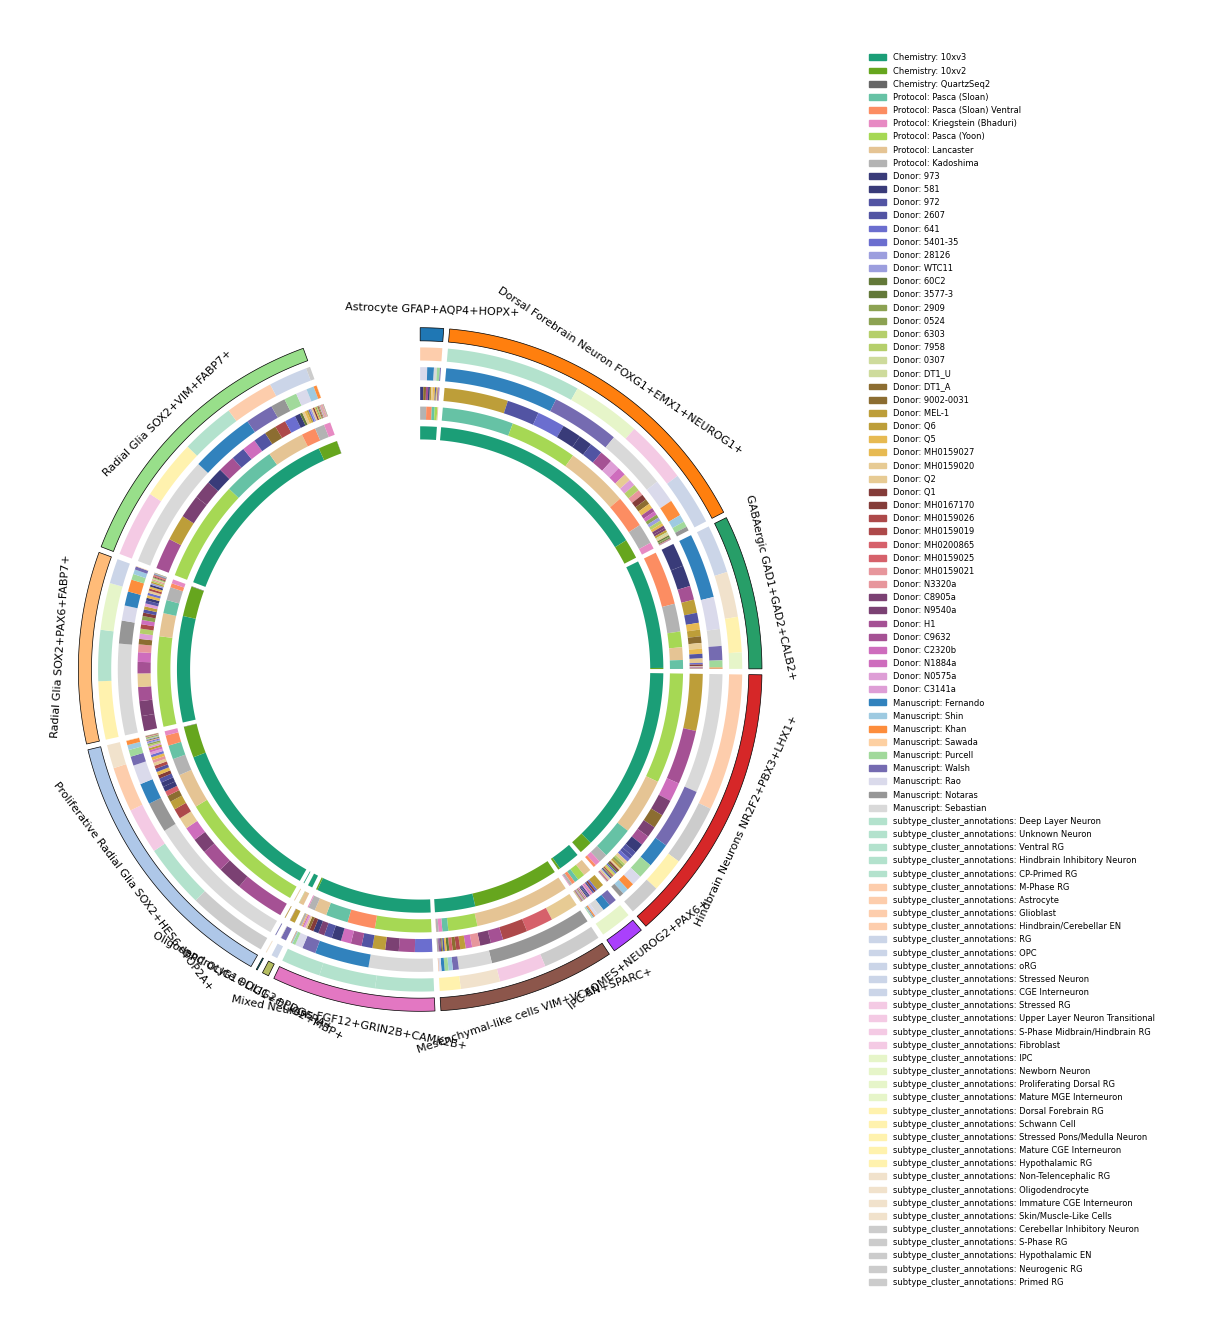

In [70]:
fig, circos = plot_circos_layers(
    adata,
    outer_col="CellType",
    sector_space=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 20],
    outer_cmap=adata.uns["CellType_colors"],
    track_layout=[
        ("Chemistry", 4),
        ("Protocol", 4),
        ("Donor", 4),
        ("Manuscript", 4),
        ("subtype_cluster_annotations", 4),
    ],
    spacing=2,
    legend=True,
    cmaps = ["Dark2", "Set2", "tab20b",  "tab20c", "Pastel2"], 
    savefig="/home/deepak/datasets/scz_meta_analysis/panels/Fig_1_Circos_All_Layers_w_Legend")

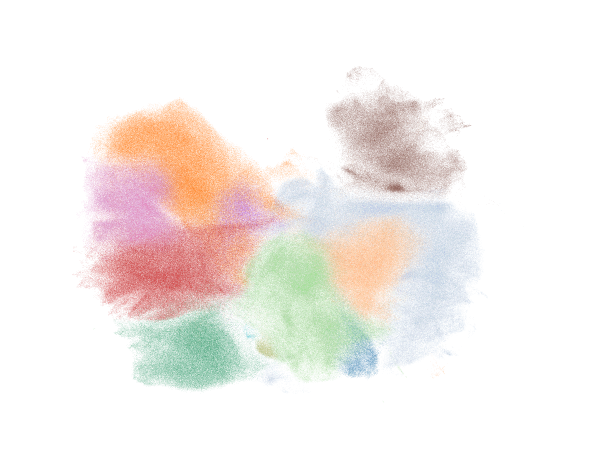

In [25]:
fig, ax = plt.subplots()

sc.pl.umap(adata, color='CellType', ax=ax, show=False, legend_loc=None)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_1_CellType_UMAP.png", 
            dpi=500, bbox_inches="tight", pad_inches=0, transparent=True,)
plt.show()

In [13]:
## Import Subclass DGES ##

celltype_dge_list = []
for file_path in glob.glob('/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/one_vs_all/CellType/DE_*'):
    dge = pd.read_csv(file_path, index_col=0)
    celltype_dge_list.append(dge)

celltype_dges = pd.concat(celltype_dge_list, axis=0)

celltype_dges.rename({'class':'CellType'}, axis=1, inplace=True)

celltype_dges['neglogP'] = -np.log10(celltype_dges['adj.P.Val'] )

In [14]:
# Set Subclass Order
subclass_clusters = ['Proliferative Radial Glia SOX2+HES6+TOP2A+',
 'Radial Glia SOX2+VIM+FABP7+',
 'Radial Glia SOX2+PAX6+FABP7+',
 'IPC EOMES+NEUROG2+PAX6+',
 'Mixed Neurons FGF12+GRIN2B+CAMK2B+',
 'Hindbrain Neurons NR2F2+PBX3+LHX1+',
 'GABAergic GAD1+GAD2+CALB2+',
 'Mesenchymal-like cells VIM+VCAN+SPARC+',
 'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+',
 'OPC OLIG1+OLIG2+PDGFRA+',
 'Oligodendrocyte OLIG1+OLIG2+MBP+',
 'Astrocyte GFAP+AQP4+HOPX+']

#subclass_clusters.reverse()

# Remove Stressed Glia
celltype_dges = celltype_dges[celltype_dges['CellType'].isin(subclass_clusters)]

# Prep Plot #

# excise necessary columns
plot_df = celltype_dges[['logFC', 'neglogP', 'CellType']].copy()
plot_df['gene'] = plot_df.index  

# set category ordering
plot_df['CellType'] = pd.Categorical(plot_df['CellType'], categories=subclass_clusters, ordered=True)
plot_df = plot_df.sort_values(by='CellType') 
gene_order = plot_df['CellType'].str.split(' ').apply(lambda x: x[-1]).str.strip('+').str.split('+').explode().unique().tolist()
#gene_order.reverse()
plot_df['gene'] = pd.Categorical(plot_df['gene'], categories=gene_order, ordered=True)

# useful genes
plot_df = plot_df[plot_df['gene'].isin(gene_order)]

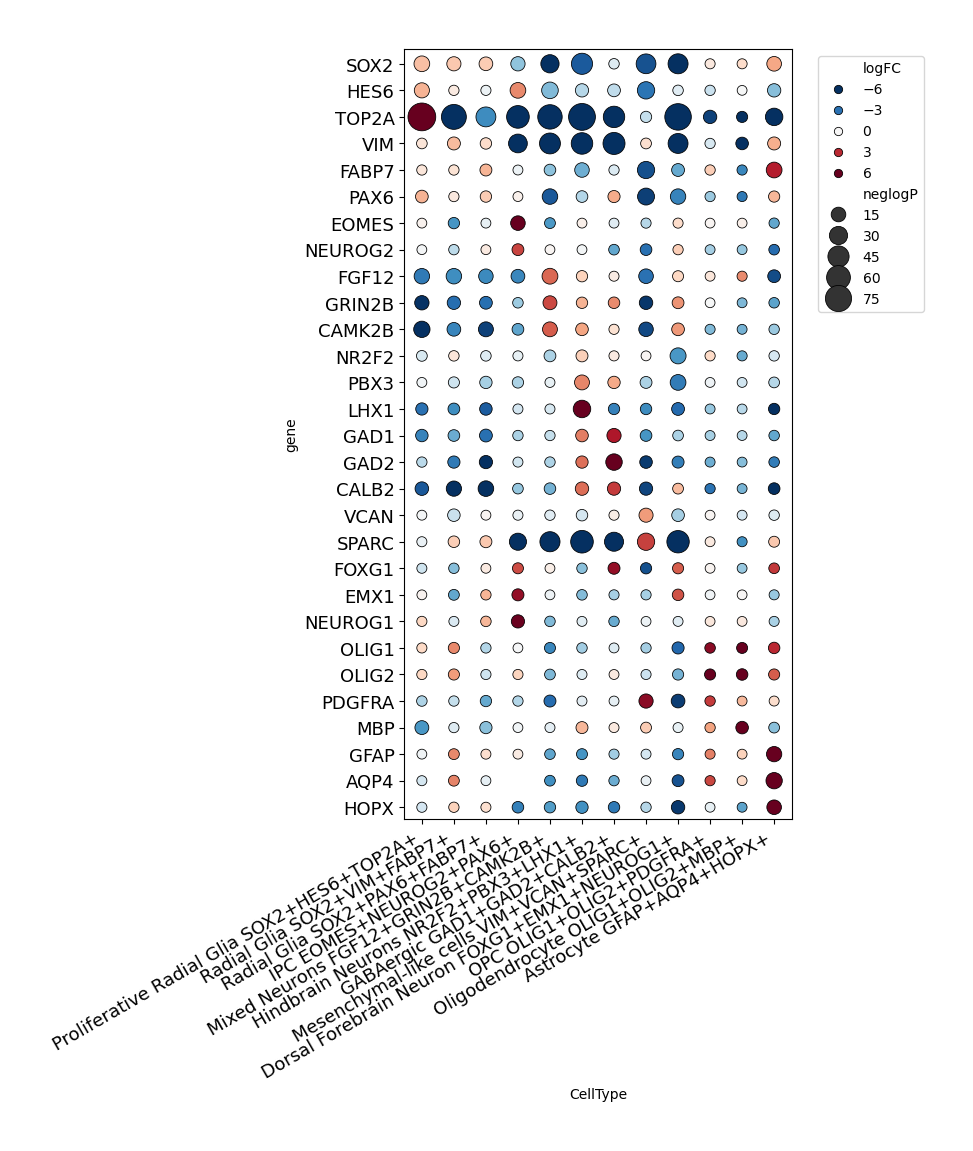

In [15]:
plt.figure(figsize=(5, 10))

sns.scatterplot(
    data=plot_df,
    x='CellType',
    y='gene',
    size='neglogP',
    hue='logFC',
    palette='RdBu_r',
    hue_norm=(-4, 4),
    sizes=(50, 400),
    edgecolor='black')

plt.xticks(rotation=30, ha='right')
plt.gca().tick_params(axis='both', labelsize=13)  # adjust size as you like
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(len(plot_df['gene'].unique()) - 0.55, -0.55)
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_1_DotPlot_Subclass_Markers_Long.svg", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
subclass_clusters.reverse()
gene_order.reverse()

plot_df['CellType'] = pd.Categorical(plot_df['CellType'], categories=subclass_clusters, ordered=True)
plot_df['gene'] = pd.Categorical(plot_df['gene'], categories=gene_order, ordered=True)

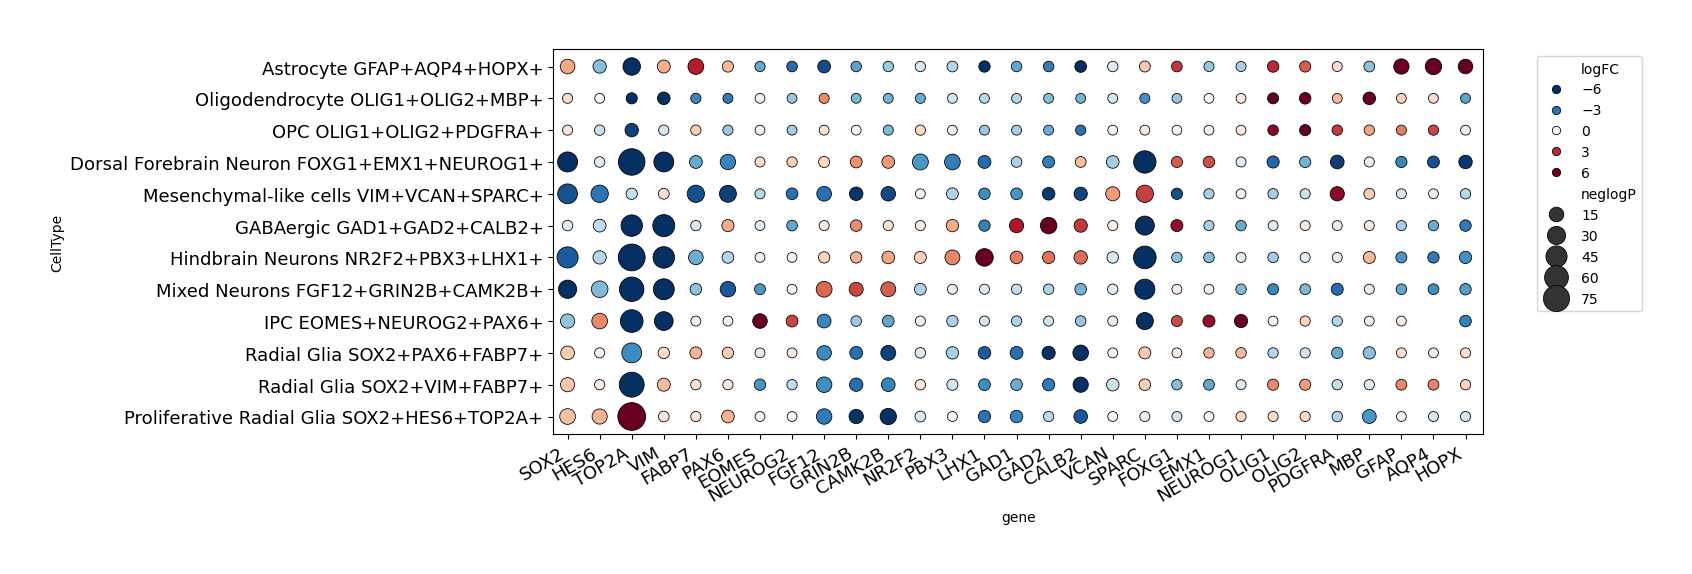

In [18]:
plt.figure(figsize=(12, 5))

sns.scatterplot(
    data=plot_df,
    y='CellType',
    x='gene',
    size='neglogP',
    hue='logFC',
    palette='RdBu_r',
    hue_norm=(-4, 4),
    sizes=(50, 400),
    edgecolor='black')

plt.xticks(rotation=30, ha='right')
plt.gca().tick_params(axis='both', labelsize=13)  # adjust size as you like
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(len(plot_df['gene'].unique()) -.55, -.55)
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_1_DotPlot_Subclass_Markers_Wide.svg", dpi=300, bbox_inches="tight")
plt.show()

In [50]:
## Quick Psudotime Image ##

# neighbors first
sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=15)

# diffusion map
sc.tl.diffmap(adata)

# choose root cell
root_cell = np.where((adata.obs["subclass_annotations_markers"] == "Proliferative Radial Glia SOX2+HES6+TOP2A+") &
                     (adata.obs["Day"] == adata.obs["Day"].min()))[0][0]

adata.uns["iroot"] = root_cell

# diffusion pseudotime
sc.tl.dpt(adata)

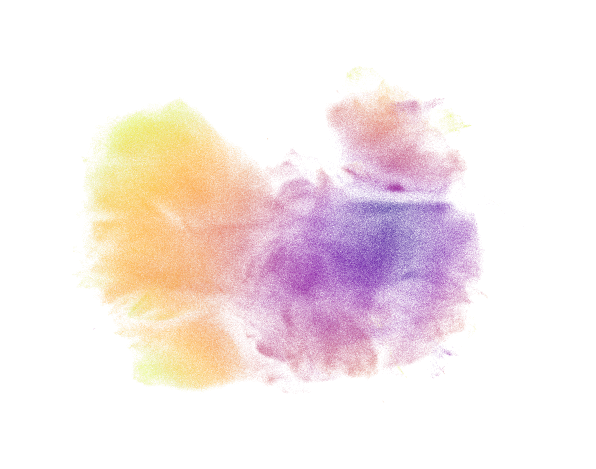

In [62]:
fig, ax = plt.subplots()

sc.pl.umap(adata, color="dpt_pseudotime", cmap="plasma", vmax='p99', frameon=False, ax=ax, colorbar_loc=None, show=False)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_1_dpt_pseudotime_UMAP.png", 
            dpi=500, bbox_inches="tight", pad_inches=0, transparent=True)

plt.show()